In [1]:
# Sentiment Analysis using NLP Pipeline & ML Models

"""
Objective:
Build an end-to-end sentiment analysis system using NLP preprocessing,
feature engineering, and multiple ML models. Compare performance.
"""


'\nObjective:\nBuild an end-to-end sentiment analysis system using NLP preprocessing,\nfeature engineering, and multiple ML models. Compare performance.\n'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

[nltk_data] Downloading package stopwords to C:\Users\Janu
[nltk_data]     V\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Janu
[nltk_data]     V\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Janu
[nltk_data]     V\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/IMDB-Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Shape: (50000, 2)


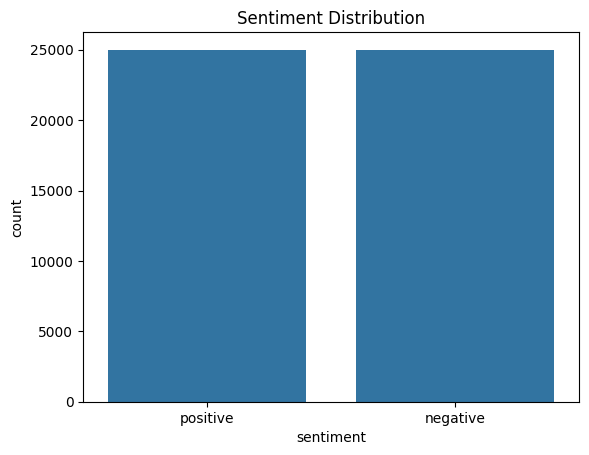

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [4]:
print("Shape:", df.shape)

# Class distribution
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

# Sample data
df['review'][0]

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()  # lowercasing
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-zA-Z]", " ", text)  # remove punctuation
    tokens = text.split()  # tokenization
    
    tokens = [word for word in tokens if word not in stop_words]  # remove stopwords
    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # lemmatization
    
    return " ".join(tokens)

df['clean_text'] = df['review'].apply(preprocess)

In [6]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['sentiment'], test_size=0.2, random_state=42
)

In [8]:
bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [9]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [10]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

lr_pred = lr.predict(X_test_tfidf)

In [11]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

nb_pred = nb.predict(X_test_tfidf)

In [14]:
dt = DecisionTreeClassifier(max_depth=10)
dt.fit(X_train_tfidf, y_train)

dt_pred = dt.predict(X_test_tfidf)

In [15]:
def evaluate(y_test, y_pred, model_name):
    print(f"\n{model_name} Performance:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

In [16]:
evaluate(y_test, lr_pred, "Logistic Regression")
evaluate(y_test, nb_pred, "Naive Bayes")
evaluate(y_test, dt_pred, "Decision Tree")


Logistic Regression Performance:
Accuracy: 0.8886
Precision: 0.8790805485802589
Recall: 0.9031553879738043
F1 Score: 0.8909553641346907

Naive Bayes Performance:
Accuracy: 0.8554
Precision: 0.8523239850951166
Recall: 0.8624727128398492
F1 Score: 0.8573683172223318

Decision Tree Performance:
Accuracy: 0.7286
Precision: 0.689795918367347
Recall: 0.8384600119071244
F1 Score: 0.7568971694733071


In [17]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, dt_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, nb_pred),
        f1_score(y_test, dt_pred)
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.8886,0.890955
1,Naive Bayes,0.8554,0.857368
2,Decision Tree,0.7286,0.756897


In [20]:
# Insights:

'''1. Preprocessing significantly improved model performance by removing noise.
2. TF-IDF performed better than Bag of Words as it captures word importance.
3. Logistic Regression achieved the best accuracy and F1-score.
4. Naive Bayes performed well but slightly lower than Logistic Regression.
5. Decision Tree showed lower performance due to overfitting.
6. Proper text cleaning and lemmatization helped in better feature extraction.'''

'1. Preprocessing significantly improved model performance by removing noise.\n2. TF-IDF performed better than Bag of Words as it captures word importance.\n3. Logistic Regression achieved the best accuracy and F1-score.\n4. Naive Bayes performed well but slightly lower than Logistic Regression.\n5. Decision Tree showed lower performance due to overfitting.\n6. Proper text cleaning and lemmatization helped in better feature extraction.'

In [21]:
# Conclusion:
'''
An end-to-end NLP pipeline was successfully built. Among all models,
Logistic Regression with TF-IDF gave the best results.'''

'\nAn end-to-end NLP pipeline was successfully built. Among all models,\nLogistic Regression with TF-IDF gave the best results.'